In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
LOG_DIR = "../../logs"
EVENTS_FILE_PATTERN = os.path.join(LOG_DIR, "events_2025-10-25T22:55:09.013198")
ALERTS_FILE = os.path.join(LOG_DIR, "overheating_alerts")

OUTPUT_STATS_FILE = "analise_latencia.txt"
OUTPUT_BOXPLOT_FILE = "grafico_latencia_boxplot.png"
OUTPUT_HISTOGRAM_FILE = "grafico_latencia_histograma.png"

def load_jsonl_logs(file_path: str) -> pd.DataFrame:
    """Carrega um único arquivo JSONL para um DataFrame."""
    return pd.read_json(file_path, lines=True)

def clean_alert_data(df_alerts: pd.DataFrame) -> pd.DataFrame:
    df_alerts = df_alerts.rename(columns={'timestamp': 't_deteccao'})
    df_alerts['t_deteccao'] = pd.to_datetime(df_alerts['t_deteccao'])
    return df_alerts[['event_id', 't_deteccao']]

def clean_event_data(df_events: pd.DataFrame) -> pd.DataFrame:
    df_events = df_events.rename(columns={'timestamp': 't_geracao'})
    df_events['t_geracao'] = pd.to_datetime(df_events['t_geracao'])
    return df_events[['event_id', 't_geracao', 'sensor_id']]

def get_experiment_data(events_file: str, alerts_file: str, num_sensors: int, sample: int = None) -> pd.DataFrame:
    df_events = load_jsonl_logs(events_file)
    df_alerts = load_jsonl_logs(alerts_file)

    df_events_clean = clean_event_data(df_events)
    df_alerts_clean = clean_alert_data(df_alerts)

    print("Mesclando logs de eventos e alertas...")
    df_merged = pd.merge(df_events_clean, df_alerts_clean, on='event_id', how="inner")
    df_merged['latencia_ms'] = (df_merged["t_deteccao"] - df_merged["t_geracao"]).dt.total_seconds() * 1000
    df_merged['num_sensors'] = [num_sensors] * len(df_merged)

    if sample:
        return df_merged.sample(sample)
    else:
        return df_merged

In [25]:
file_sampling_map = {file: load_jsonl_logs(file).shape[0] for file in [
    #"logs/alerts_1_engines",
    #"logs/alerts_2_engines",
    "logs/alerts_3_engines",
    "logs/alerts_4_engines"
]}

for file, samples in file_sampling_map.items():
    print(f"Arquivo: {file}", f"- Amostras: {samples}")

min_sampling = min(file_sampling_map.values())
min_sampling

Arquivo: logs/alerts_3_engines - Amostras: 560
Arquivo: logs/alerts_4_engines - Amostras: 790


560

In [26]:
experiment_df = pd.concat([
    #get_experiment_data("logs/events_1_engines", "logs/alerts_1_engines", num_sensors=1, sample=min_sampling),
    #get_experiment_data("logs/events_2_engines", "logs/alerts_2_engines", num_sensors=2, sample=min_sampling),
    get_experiment_data("logs/events_3_engines", "logs/alerts_3_engines", num_sensors=3, sample=min_sampling),
    get_experiment_data("logs/events_4_engines", "logs/alerts_4_engines", num_sensors=4, sample=min_sampling)
])

Mesclando logs de eventos e alertas...
Mesclando logs de eventos e alertas...


In [27]:
series = experiment_df.groupby('num_sensors')['latencia_ms'].apply(list)

In [28]:
experiment_df.groupby('num_sensors')['latencia_ms'].mean()

num_sensors
3    67.531613
4    48.793209
Name: latencia_ms, dtype: float64

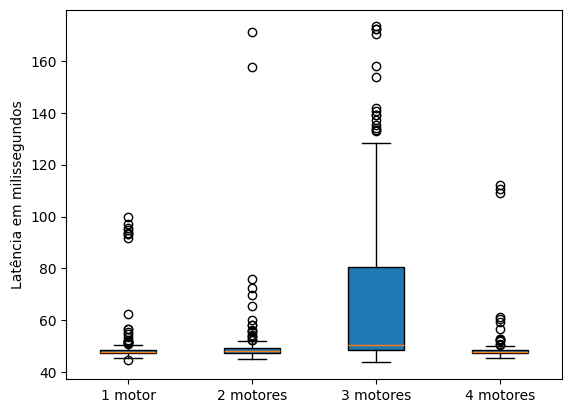

In [24]:
fig, ax = plt.subplots()
ax.set_ylabel('Latência em milissegundos')

labels = ["1 motor", "2 motores", "3 motores", "4 motores"]

bplot = ax.boxplot(series,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)  # will be used to label x-ticks

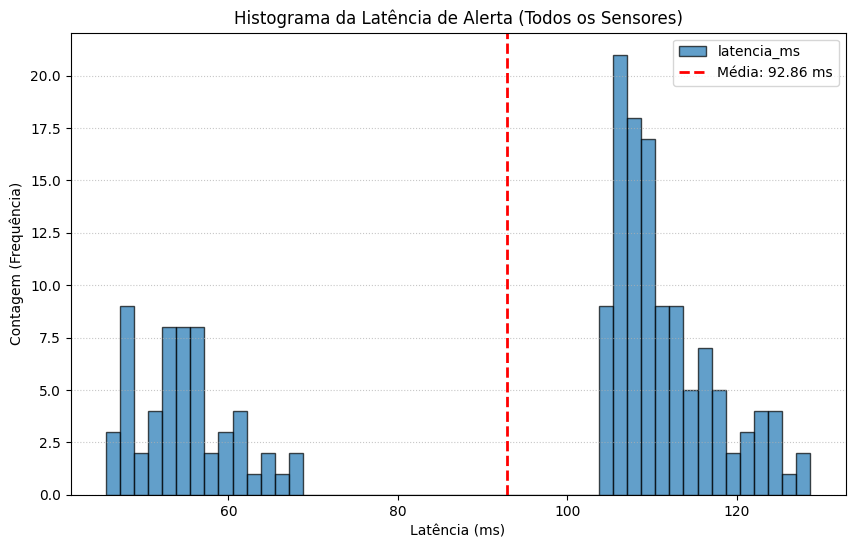

In [109]:
one_engine_df = experiment_df[experiment_df["num_sensors"] == 1]

mean_latency = one_engine_df['latencia_ms'].mean()

plt.figure(figsize=(10, 6))

# Plota o histograma
one_engine_df['latencia_ms'].plot(
    kind='hist',    # Tipo histograma
    bins=50,        # Número de "barras"
    ec='black',     # Cor da borda das barras (edgecolor)
    alpha=0.7,      # Transparência
    label='latencia_ms' # Nome para a legenda
)

# Adiciona a linha da média (como na sua imagem)
plt.axvline(
    mean_latency,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Média: {mean_latency:.2f} ms" # Legenda dinâmica
)

# Títulos e rótulos (como na sua imagem)
plt.title('Histograma da Latência de Alerta (Todos os Sensores)')
plt.xlabel('Latência (ms)')
plt.ylabel('Contagem (Frequência)')

# Adiciona a legenda e o grid
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7) # Grid horizontal pontilhado